# Probabilistic Latent Semantic Indexing (PLSI)

PLSI is the maximum-likelihood ancestor of LDA: the same "documents are mixtures of word-topics" factorization, but without a prior. Working through it teaches a deep lesson in modeling - what a Bayesian prior actually buys you - because PLSI's two weaknesses (it overfits, and it cannot represent a document it didn't train on) are exactly what LDA's Dirichlet prior fixes.

> Reference: Hofmann, "Probabilistic Latent Semantic Indexing" (https://dl.acm.org/doi/10.1145/312624.312649), SIGIR 1999.


## PLSI as a factorization of co-occurrence

Probabilistic latent semantic indexing models the probability of word $w$ in document $d$ as a mixture
over latent topics $z$,
$$p(w\mid d) = \sum_{z} p(w\mid z)\,p(z\mid d).$$
Collecting these into matrices, the word-by-document matrix $P$ factorizes as $P \approx B\,\Theta$, with
$B$ the word-topic matrix (columns are topics) and $\Theta$ the topic-document matrix, both with
nonnegative, column-normalized entries.

Theorem (PLSI is nonnegative matrix factorization with KL loss). Maximizing the PLSI log-likelihood of
the observed counts is equivalent to minimizing the (generalized) KL divergence between the empirical
co-occurrence matrix and the low-rank product $B\Theta$, which is exactly nonnegative matrix
factorization under the KL objective. The EM updates for PLSI coincide with the multiplicative update
rules for KL-NMF.

Proof idea. The expected complete-data log-likelihood, summed over word tokens with their counts, equals
(up to constants) $\sum_{w,d} n(w,d)\log\sum_z B_{wz}\Theta_{zd}$, whose maximization is the KL-NMF
objective; the EM E-step computes the responsibilities $p(z\mid w,d)$ and the M-step renormalizes, which
are the NMF multiplicative updates. $\quad\blacksquare$

## Why PLSI is not a generative model, and overfits

PLSI learns a separate topic distribution $p(z\mid d)$ for every training document. The number of
parameters therefore grows with the corpus size.

Theorem (no generative process for documents). PLSI places no prior on $p(z\mid d)$; the document mixing
weights are free parameters fit to the training set. Consequently the model is transductive: it cannot
assign a probability to a document outside the training corpus, and the parameter count grows linearly in
the number of documents, so it overfits and does not generalize at the document level.

Counterexample (a new document has no place). Given an unseen document, PLSI has no $p(z\mid d)$ for it
and no rule to generate one, so it cannot score the document without re-fitting. This is the precise gap
that latent Dirichlet allocation closes by putting a Dirichlet prior on the topic proportions, turning
the free per-document parameters into draws from a shared distribution. The applied section shows the
overfitting symptom; the LDA notebook supplies the fix and the de Finetti justification for it.

## 1. From LDA to PLSI: the same factorization, a different philosophy

PLSI models the probability of word $w$ in document $d$ as a mixture over $K$ latent topics:

$$P(w \mid d) = \sum_{z=1}^{K} \underbrace{P(w \mid z)}_{\text{shared topic-word}}\; \underbrace{P(z \mid d)}_{\text{per-document mixture}}.$$

This is identical to LDA's per-document mixture - but PLSI treats $P(z \mid d)$ as free parameters fit by maximum likelihood, one vector per document, with no prior. LDA instead puts a Dirichlet prior on those mixtures and integrates over them. That single difference has three consequences worth internalizing:

1. The parameter count grows with the corpus. PLSI has $K \times (\text{#documents})$ document-topic parameters. More data does not pin down a fixed model - it adds parameters. This is the classic sign of a model that will overfit.
2. There is no prior to regularize. LDA's $\alpha<1$ pulls mixtures toward sparsity; PLSI has nothing pulling it anywhere, so it fits the training documents as tightly as $K$ allows.
3. It is transductive - it cannot score a new document. $P(z\mid d)$ only exists for documents seen during training. To place a new document you must run a separate "folding-in" optimization. LDA's posterior, by contrast, gives any new document a topic vector for free.

So PLSI is the perfect foil: we'll fit it, see it works transductively (retrieval among the training documents is good), and use those three points to understand precisely what the Bayesian machinery in LDA is for. In mixle, `IntegerPLSIDistribution` exposes `state_mat` ($P(z\mid d)$, one row per document) and `prob_mat` ($P(w\mid z)$, the shared topics).


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

from mixle.stats.latent.integer_probabilistic_latent_semantic_indexing import IntegerProbabilisticLatentSemanticIndexingEstimator
from mixle.inference.estimation import optimize
from mixle.utils.optsutil import count_by_value

DATA = '../../data'
t0 = time.time()

def load_stop_words(path):
    with open(path, 'rt') as fh:
        return set(fh.read().split('\n')) | {''}

STOP = load_stop_words(os.path.join(DATA, 'stop_words', 'mallet.txt'))

def load_wiki(wiki_dir):
    # one document per line; the filename (minus .txt) is the category label;
    # drop MALLET stop words so topics reflect content, not function words
    labelled = []
    for fname in sorted(f for f in os.listdir(wiki_dir) if f.endswith('.txt')):
        label = fname[:-4]
        with open(os.path.join(wiki_dir, fname), 'rt') as fh:
            labelled += [(label, [w for w in line.lower().strip().split(' ') if w not in STOP]) for line in fh]
    labelled = [(lbl, toks) for lbl, toks in labelled if len(toks) > 1]
    vocab = sorted({w for _, toks in labelled for w in toks})
    wmap = {w: i for i, w in enumerate(vocab)}
    labels = [lbl for lbl, _ in labelled]
    # PLSI wants (doc_id, [(word_id, count), ...])
    docs = [(i, list(count_by_value([wmap[w] for w in toks]).items()))
            for i, (_, toks) in enumerate(labelled)]
    return docs, labels, vocab

docs, labels, vocab = load_wiki(os.path.join(DATA, 'wiki_example'))
categories = sorted(set(labels))
label_id = np.array([categories.index(l) for l in labels])
print('documents: %d | vocabulary: %d | categories: %d' % (len(docs), len(vocab), len(categories)))
print('categories:', categories)

documents: 879 | vocabulary: 19078 | categories: 9
categories: ['Death', 'Entertainment', 'Food', 'Investing', 'Mathematics', 'Medicine', 'Politics', 'Sports', 'War']


## 2. Fitting PLSI by EM

PLSI is fit by expectation-maximization: the E-step computes the posterior topic responsibilities for each word occurrence, the M-step re-estimates $P(w\mid z)$ and $P(z\mid d)$. We fit $K=10$ topics and track the training log-likelihood - for PLSI this curve climbs monotonically and keeps climbing with $K$, which is itself the overfitting tell we'll return to.


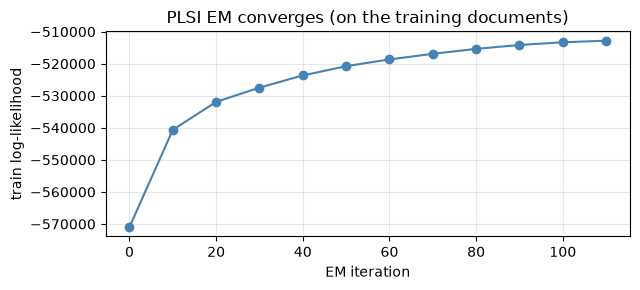

In [2]:
K = 10
est = IntegerProbabilisticLatentSemanticIndexingEstimator(len(vocab), K, len(docs), pseudo_count=(1, 1, 1))

def total_ll(m):
    return float(np.sum(m.seq_log_density(m.dist_to_encoder().seq_encode(docs))))

model = optimize(docs, est, max_its=10, rng=np.random.RandomState(2), print_iter=100)
trace = [total_ll(model)]
for _ in range(11):                       # ~120 EM iterations total
    model = optimize(docs, est, max_its=10, prev_estimate=model, print_iter=100)
    trace.append(total_ll(model))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(np.arange(len(trace)) * 10, trace, 'o-', color='steelblue')
ax.set_xlabel('EM iteration'); ax.set_ylabel('train log-likelihood'); ax.grid(alpha=0.3)
ax.set_title('PLSI EM converges (on the training documents)')
plt.tight_layout(); plt.show()

## 3. Reading the model: topics and a document's mixture

`prob_mat[:, z]` is topic $z$'s distribution over the vocabulary; its top words name it. `state_mat[d]` is document $d$'s topic mixture - the compact representation we recommend with.


In [3]:
inv = {i: w for i, w in enumerate(vocab)}
for z in range(K):
    top = np.argsort(-model.prob_mat[:, z])[:10]
    print('topic %2d: %s' % (z, ', '.join(inv[j] for j in top)))

d = int(np.argmax([sum(c for _, c in doc[1]) for doc in docs]))   # a long, well-represented document
print('\ndocument %d  category=%s  (%d tokens)' % (d, labels[d], sum(c for _, c in docs[d][1])))
print('topic mixture P(z|d):', np.round(model.state_mat[d], 3))

topic  0: film, sports, events, music, audience, entertainment, performance, art, century, festival
topic  1: blood, heart, oxygen, system, animals, body, cells, called, left, lungs
topic  2: science, mathematics, greek, mathematical, philosophy, century, ancient, theory, study, modern
topic  3: body, water, mortis, acid, form, called, death, matter, fatty, skin
topic  4: political, government, games, sports, game, states, state, international, system, power
topic  5: english, time, leisure, word, social, people, activities, term, called, dance
topic  6: medical, disease, health, death, food, medicine, person, people, include, diagnosis
topic  7: food, species, plant, plants, world, fruit, numbers, seeds, family, number
topic  8: war, military, warfare, medicine, enemy, strategy, forces, term, weapons, strategic
topic  9: investment, market, financial, capital, money, company, stock, economic, interest, finance

document 592  category=Politics  (225 tokens)
topic mixture P(z|d): [0.001

## 4. Recommendation by topic-vector similarity

Two documents are "similar" if their topic mixtures point the same way: we score with the cosine similarity of their `state_mat` rows. Ordering all documents by similarity to each query gives a recommendation list. Because the documents are stored grouped by category, the cosine-similarity matrix shows visible block structure - same-category documents cluster.

Note the evaluation is leave-one-out among the training documents: PLSI has no representation for a held-out document, so (unlike LDA) we cannot evaluate on a separate test split without folding-in. We rank every other training document and ask how far down the list the first same-category neighbor sits - `hit@k`. (A caveat that is itself instructive: short documents get near one-hot topic vectors that tie at cosine 1, so their recommendations are unreliable - the more tokens a document has, the more trustworthy its PLSI representation, which is why the worked example below uses a long document.)


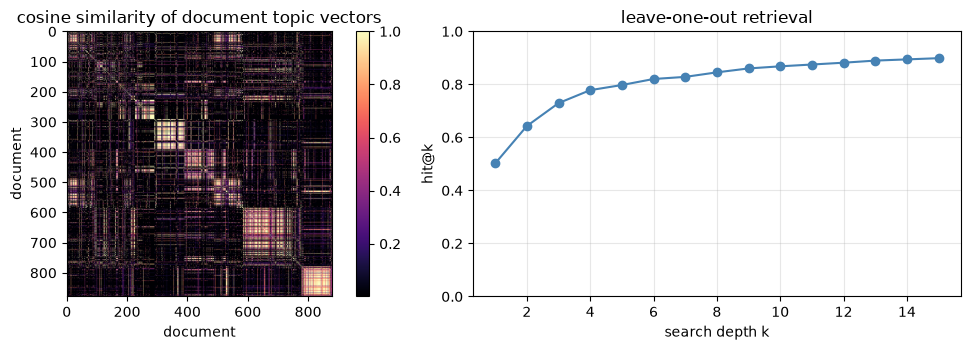

hit@1=0.502  hit@5=0.797  hit@10=0.868

query doc 592 (category=Politics) -> top recommendations:
  1. doc 605  category=Politics  cos=1.000
  2. doc 659  category=Politics  cos=1.000
  3. doc 663  category=Politics  cos=1.000
  4. doc 776  category=Sports  cos=1.000
  5. doc 681  category=Politics  cos=0.999
  6. doc 645  category=Politics  cos=0.999


In [4]:
S = model.state_mat / np.linalg.norm(model.state_mat, axis=1, keepdims=True)
cos = S @ S.T

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
im = ax[0].imshow(cos, cmap='magma'); ax[0].set_title('cosine similarity of document topic vectors')
ax[0].set_xlabel('document'); ax[0].set_ylabel('document'); fig.colorbar(im, ax=ax[0], fraction=0.046)

sim = cos.copy(); np.fill_diagonal(sim, -np.inf)        # leave-one-out
order = np.argsort(-sim, axis=1)
max_depth = 15
hit = np.array([[ (label_id[order[i, :k]] == label_id[i]).any() for k in range(1, max_depth + 1)]
                for i in range(len(docs))]).mean(axis=0)
ax[1].plot(range(1, max_depth + 1), hit, 'o-', color='steelblue')
ax[1].set_xlabel('search depth k'); ax[1].set_ylabel('hit@k'); ax[1].set_ylim(0, 1); ax[1].grid(alpha=0.3)
ax[1].set_title('leave-one-out retrieval')
plt.tight_layout(); plt.show()
print('hit@1=%.3f  hit@5=%.3f  hit@10=%.3f' % (hit[0], hit[4], hit[9]))

# a concrete recommendation list for the long document chosen above
nbr = np.argsort(-sim[d])[:6]
print('\nquery doc %d (category=%s) -> top recommendations:' % (d, labels[d]))
for r, j in enumerate(nbr, 1):
    print('  %d. doc %d  category=%s  cos=%.3f' % (r, j, labels[j], cos[d, j]))

## 5. The PLSI lesson: why LDA added a prior

The retrieval above is good - transductively. The model has learned a sensible topic geometry over the documents it saw. But notice what we could not do that we did freely in the LDA notebook:

- We never evaluated on a held-out test split, because PLSI has no $P(z\mid d)$ for an unseen $d$. Generalization to new documents requires a separate folding-in optimization per document.
- The training log-likelihood in §2 rises without bound as we add topics, because each new topic adds free per-document parameters with nothing to penalize the extra flexibility - the textbook overfitting signature.

LDA fixes both with one idea: replace the free per-document parameters with a Dirichlet prior and integrate them out. The prior regularizes (curing the overfitting) and, because it defines a distribution over any mixture, gives new documents a posterior for free (curing the transductive limitation). PLSI is therefore the clearest possible motivation for going Bayesian: you can see exactly which problem each piece of LDA's machinery solves.


## Score topics with UMass coherence

"Eyeballing" the top words is subjective. Topic coherence quantifies how often a topic's top words co-occur in documents; the UMass score (Mimno et al. 2011) is $\sum_{i<j}\log\frac{D(w_i,w_j)+1}{D(w_j)}$ over the top words (less negative = more coherent) and correlates with human judgements. We rank the learned topics by coherence to find the strong and weak ones automatically.


In [5]:
from collections import Counter
doc_sets = [set(w for w, _ in doc[1]) for doc in docs]
df = Counter(w for s in doc_sets for w in s)
def cooc(a, b):
    return sum(1 for s in doc_sets if a in s and b in s)
def umass(words):
    tot, m = 0.0, 0
    for i in range(1, len(words)):
        for j in range(i):
            tot += np.log((cooc(words[i], words[j]) + 1) / max(df[words[j]], 1)); m += 1
    return tot / m
coh = {z: umass(list(np.argsort(-model.prob_mat[:, z])[:10])) for z in range(K)}
for z in sorted(coh, key=coh.get, reverse=True):
    print('topic %2d  UMass coherence = %6.2f   %s' %
          (z, coh[z], ', '.join(inv[j] for j in np.argsort(-model.prob_mat[:, z])[:6])))
print('mean coherence = %.2f; the bottom topic is the one to inspect or prune.' % np.mean(list(coh.values())))

topic  2  UMass coherence =  -1.24   science, mathematics, greek, mathematical, philosophy, century
topic  9  UMass coherence =  -1.28   investment, market, financial, capital, money, company
topic  1  UMass coherence =  -1.50   blood, heart, oxygen, system, animals, body
topic  6  UMass coherence =  -1.63   medical, disease, health, death, food, medicine
topic  7  UMass coherence =  -1.66   food, species, plant, plants, world, fruit
topic  8  UMass coherence =  -1.73   war, military, warfare, medicine, enemy, strategy
topic  0  UMass coherence =  -1.76   film, sports, events, music, audience, entertainment
topic  4  UMass coherence =  -1.77   political, government, games, sports, game, states
topic  5  UMass coherence =  -1.87   english, time, leisure, word, social, people
topic  3  UMass coherence =  -2.30   body, water, mortis, acid, form, called
mean coherence = -1.67; the bottom topic is the one to inspect or prune.


## References

- Hofmann, T. (1999). Probabilistic latent semantic indexing (https://doi.org/10.1145/312624.312649). SIGIR.
- Deerwester, S. et al. (1990). Indexing by latent semantic analysis (https://doi.org/10.1002/(SICI)1097-4571(199009)41:6%3C391::AID-ASI1%3E3.0.CO;2-9). JASIS 41(6), 391-407. - LSA, the SVD ancestor.
- Blei, D. M., Ng, A. Y. & Jordan, M. I. (2003). Latent Dirichlet Allocation (https://jmlr.org/papers/v3/blei03a.html). JMLR 3, 993-1022.
- Girolami, M. & Kabán, A. (2003). On an equivalence between PLSI and LDA (https://doi.org/10.1145/860435.860537). SIGIR.


## Exercises and extensions

1. Watch PLSI overfit. Refit for $K \in \{5,\dots,80\}$ and plot final training log-likelihood vs $K$ (monotonically increasing); contrast with LDA's bounded held-out likelihood and explain why training likelihood is useless for choosing $K$ in PLSI (Hofmann; Blei et al.).
2. Folding-in. Implement folding-in for a held-out document - fix the topic-word distributions and EM-optimize only the new document's topic vector - and compare its retrieval to the transductive numbers; quantify the cost of PLSI's lack of a generative document model.
3. PLSI ≈ LDA with a uniform Dirichlet. Empirically explore the Girolami-Kabán (2003) equivalence: as the LDA Dirichlet concentration grows, its MAP topic mixtures approach PLSI's; demonstrate the connection on the same corpus.
4. LSA vs PLSI vs LDA. Add an SVD-based LSA baseline (Deerwester et al.) and compare all three on the retrieval task; discuss the probabilistic models' advantages (interpretability, generative scoring).
